# Fake news detection - CNN

* Load both CSV files
* Add a label column (FAKE or REAL)
* Combine into a single dataset

In [34]:
# import libraries
import pandas as pd
import numpy as np
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from gensim.models import Word2Vec
from scipy.sparse import hstack


# Make sure you have the required resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sumantarout/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/sumantarout/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/sumantarout/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/sumantarout/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# CNN Deep Learning Setup

This section adds Convolutional Neural Network (CNN) capabilities for fake news detection, implementing state-of-the-art deep learning approaches that can capture complex textual patterns and semantic relationships.

In [35]:
# Deep Learning imports for CNN
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Conv1D, MaxPooling1D, GlobalMaxPooling1D, 
    Embedding, Dropout, Flatten, Input, Concatenate,
    GlobalAveragePooling1D, SpatialDropout1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow.keras.backend as K

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.experimental.list_physical_devices('GPU')) > 0}")

# CNN Configuration - Updated embedding_dim to match Word2Vec model (50 dimensions)
CNN_CONFIG = {
    'max_features': 20000,      # Maximum number of words to keep in vocabulary
    'max_len': 500,             # Maximum sequence length
    'embedding_dim': 50,        # Embedding dimension (matches Word2Vec model)
    'batch_size': 32,           # Batch size for training
    'epochs': 10,               # Number of training epochs
    'validation_split': 0.2,    # Validation split ratio
    'test_size': 0.2           # Test set size
}

print("CNN Configuration loaded:", CNN_CONFIG)
print("🔧 Fixed: embedding_dim set to 50 to match pre-trained Word2Vec model")

TensorFlow version: 2.20.0
GPU Available: False
CNN Configuration loaded: {'max_features': 20000, 'max_len': 500, 'embedding_dim': 50, 'batch_size': 32, 'epochs': 10, 'validation_split': 0.2, 'test_size': 0.2}
🔧 Fixed: embedding_dim set to 50 to match pre-trained Word2Vec model


## Text Preprocessing for CNN

CNNs require different preprocessing compared to traditional ML models:
- **Tokenization**: Convert text to sequences of integers
- **Padding**: Ensure all sequences have the same length
- **Word embeddings**: Map words to dense vector representations

In [36]:
# Load and prepare the data
print("=" * 60)
print("LOADING AND PREPARING DATA")
print("=" * 60)

# Load the datasets
try:
    df_fake = pd.read_csv("Fake.csv")
    df_true = pd.read_csv("True.csv")
    print(f"Loaded fake news dataset: {len(df_fake):,} articles")
    print(f"Loaded true news dataset: {len(df_true):,} articles")
except FileNotFoundError as e:
    print(f"Error loading data files: {e}")
    print("Please ensure the data files are in the ./ directory")
    raise

# Add labels
df_fake['label'] = 'FAKE'
df_true['label'] = 'REAL'

# Combine datasets
df_combined = pd.concat([df_fake, df_true], ignore_index=True)

# Basic text preprocessing
def basic_clean_text(text):
    """Basic text cleaning"""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

# Apply basic cleaning
df_combined['title'] = df_combined['title'].apply(basic_clean_text)
df_combined['text'] = df_combined['text'].apply(basic_clean_text)

# Create full_text column
df_combined['full_text'] = df_combined['title'] + ' ' + df_combined['text']

print(f"Combined dataset: {len(df_combined):,} articles")
print(f"Label distribution:")
print(df_combined['label'].value_counts())
print("Data loading complete!")

LOADING AND PREPARING DATA
Loaded fake news dataset: 23,481 articles
Loaded true news dataset: 21,417 articles
Loaded fake news dataset: 23,481 articles
Loaded true news dataset: 21,417 articles
Combined dataset: 44,898 articles
Label distribution:
label
FAKE    23481
REAL    21417
Name: count, dtype: int64
Data loading complete!
Combined dataset: 44,898 articles
Label distribution:
label
FAKE    23481
REAL    21417
Name: count, dtype: int64
Data loading complete!


In [37]:
# Load pre-trained Word2Vec model for embeddings
print("\n" + "=" * 60)
print("LOADING PRE-TRAINED WORD2VEC MODEL")
print("=" * 60)

try:
    import gensim.downloader as api
    
    # Load a smaller pre-trained model (50 dimensions to match CNN_CONFIG)
    print("Downloading pre-trained Word2Vec model (glove-wiki-gigaword-50)...")
    w2v_model = api.load("glove-wiki-gigaword-50")
    
    print(f"Word2Vec model loaded successfully!")
    print(f"   Vocabulary size: {len(w2v_model.key_to_index):,}")
    print(f"   Vector dimension: {w2v_model.vector_size}")
    print(f"   Matches CNN embedding_dim: {w2v_model.vector_size == CNN_CONFIG['embedding_dim']}")
    
except Exception as e:
    print(f"  Could not load pre-trained Word2Vec model: {e}")
    print("   Will use random embedding initialization instead")
    w2v_model = None

print("Ready for CNN preprocessing!")


LOADING PRE-TRAINED WORD2VEC MODEL
Word2Vec model loaded successfully!
   Vocabulary size: 400,000
   Vector dimension: 50
   Matches CNN embedding_dim: True
Ready for CNN preprocessing!
Word2Vec model loaded successfully!
   Vocabulary size: 400,000
   Vector dimension: 50
   Matches CNN embedding_dim: True
Ready for CNN preprocessing!


In [38]:
def prepare_cnn_data(df, config=CNN_CONFIG):
    """
    Prepare text data for CNN training
    
    Args:
        df: DataFrame with 'full_text' and 'label' columns
        config: Configuration dictionary
    
    Returns:
        X_train, X_val, X_test, y_train, y_val, y_test, tokenizer
    """
    print("Preparing data for CNN...")
    
    # Ensure we have full_text column
    # Combines title + text into single full_text column
    # Handles missing values with fillna("")
    # Creates unified text representation for CNN processing
    if "full_text" not in df.columns:
        df["full_text"] = df["title"].fillna("") + " " + df["text"].fillna("")
    
    # Get texts and labels
    # Converts categorical labels ('FAKE', 'REAL') → binary (1, 0)
    # Creates numerical targets for neural network training
    texts = df['full_text'].values
    labels = df['label'].values
    
    # Convert labels to binary (0: REAL, 1: FAKE)
    y_binary = (labels == 'FAKE').astype(int)
    
    print(f"   Total samples: {len(texts):,}")
    print(f"   Label distribution: {np.bincount(y_binary)}")
    
    # Initialize and fit tokenizer
    # Builds vocabulary: Maps each unique word to an integer
    # Frequency-based selection: Keeps only most frequent words
    # Handles unknown words: Uses <OOV> token for rare words
    # Removes noise: Filters out punctuation and special characters
    tokenizer = Tokenizer(
        num_words=config['max_features'],
        oov_token="<OOV>",
        filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
    )
    
    tokenizer.fit_on_texts(texts)
    # Before tokenization:
    # text = "Breaking news: Trump announces new policy"

    # After tokenization:
    # word_index = {
    #     'breaking': 1, 'news': 2, 'trump': 3, 
    #     'announces': 4, 'new': 5, 'policy': 6
    # }
    # sequence = [1, 2, 3, 4, 5, 6]
    
    # Convert texts to sequences
    # Converts each text document → list of integers
    # Maps words using the vocabulary created in Step 3
    # Unknown words become <OOV> token
    #
    # Example:
    # Input texts:
    # ["Breaking news about Trump", "Trump announces policy"]

    # Output sequences:
    # [[1, 2, 15, 3], [3, 4, 6]]  # Each number represents a word
    sequences = tokenizer.texts_to_sequences(texts)

    
    # Pad sequences to uniform length
    # Standardizes length: All sequences become exactly 500 tokens
    # Short texts: Padded with zeros at the end
    # Long texts: Truncated to 500 tokens
    #
    # Example:
    # Before padding:
    # [[1, 2, 3], [4, 5, 6, 7, 8, 9, 10]]

    # After padding (max_len=5):
    # [[1, 2, 3, 0, 0], [4, 5, 6, 7, 8]]  # Padded and truncated
    X = pad_sequences(
        sequences, 
        maxlen=config['max_len'],
        padding='post',
        truncating='post'
    )
    
    print(f"   Vocabulary size: {len(tokenizer.word_index):,}")
    print(f"   Sequence shape: {X.shape}")
    print(f"   Average sequence length: {np.mean([len(seq) for seq in sequences]):.1f}\n\n")
    
    # Split data: Train-Val-Test
    # First split: separate test set
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y_binary, 
        test_size=config['test_size'], 
        random_state=42,
        stratify=y_binary
    )
    
    # Second split: separate train and validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=config['validation_split']/(1-config['test_size']),  # Adjust for remaining data
        random_state=42,
        stratify=y_temp
    )
    
    print(f"   Train set: {X_train.shape[0]:,} samples")
    print(f"   Validation set: {X_val.shape[0]:,} samples") 
    print(f"   Test set: {X_test.shape[0]:,} samples\n\n")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, tokenizer


def create_embedding_matrix(tokenizer, embedding_dim=100):
    """
    Create embedding matrix using pre-trained word vectors
    """
    try:
        # Try to use the pre-loaded Word2Vec model
        if 'w2v_model' in globals():
            print("\n\nCreating embedding matrix from pre-trained Word2Vec...")
            word_index = tokenizer.word_index # tokenizer creates vocabulary => Maps words to unique integers
            vocab_size = len(word_index) + 1
            
            embedding_matrix = np.zeros((vocab_size, embedding_dim)) # initializes with zeros # Embedding matrix created: vocab_size × embedding_dim
            
            for word, i in word_index.items():
                if word in w2v_model.key_to_index:
                    embedding_matrix[i] = w2v_model[word][:embedding_dim]  # Truncate if needed
            
            print(f"   Pre-trained embeddings found for {np.count_nonzero(np.any(embedding_matrix, axis=1))} words")
            return embedding_matrix
            
    except Exception as e:
        print(f"   Could not load pre-trained embeddings: {e}")
    
    print("   Using random embedding initialization")
    return None  # Will use trainable embeddings => embedding_matrix = None  => Let model learn from scratch


# Prepare the data for CNN
print("=" * 60)
print("PREPARING DATA FOR CNN MODELS")
print("=" * 60)

 # Prepare data
X_train_cnn, X_val_cnn, X_test_cnn, y_train_cnn, y_val_cnn, y_test_cnn, tokenizer = prepare_cnn_data(df_combined)
# Create embedding matrix
embedding_matrix = create_embedding_matrix(tokenizer, CNN_CONFIG['embedding_dim'])

PREPARING DATA FOR CNN MODELS
Preparing data for CNN...
   Total samples: 44,898
   Label distribution: [21417 23481]
   Vocabulary size: 146,464
   Sequence shape: (44898, 500)
   Average sequence length: 428.3


   Train set: 26,938 samples
   Validation set: 8,980 samples
   Test set: 8,980 samples




Creating embedding matrix from pre-trained Word2Vec...
   Vocabulary size: 146,464
   Sequence shape: (44898, 500)
   Average sequence length: 428.3


   Train set: 26,938 samples
   Validation set: 8,980 samples
   Test set: 8,980 samples




Creating embedding matrix from pre-trained Word2Vec...
   Pre-trained embeddings found for 77523 words
   Pre-trained embeddings found for 77523 words


## CNN Model Architectures

We'll implement several CNN variants optimized for text classification:

1. **Simple 1D CNN**: Basic architecture with single filter size
2. **Multi-Filter CNN**: Multiple filter sizes to capture different n-gram patterns
3. **Deep CNN**: Multiple convolutional layers for hierarchical feature learning
4. **CNN with Global Pooling**: Different pooling strategies

In [39]:
# The create_simple_cnn function builds a straightforward 1D Convolutional Neural Network optimized for text classification.
# 1. Simplicity: Easy to understand and debug
# 2. Effectiveness: Proven architecture for text classification
# 3. Efficiency: Relatively few parameters, fast training
# 4. Interpretability: Clear feature extraction pathway
def create_simple_cnn(config=CNN_CONFIG, embedding_matrix=None):
    """
    Create a simple 1D CNN model for text classification
    """
    # Determine vocabulary size from embedding matrix if available
    vocab_size = embedding_matrix.shape[0] if embedding_matrix is not None else config['max_features']
    
    model = Sequential([
        # Embedding layer
        # Maps integers → dense vectors: Converts word IDs to 50-dimensional vectors
        # Pre-trained option: Uses Word2Vec embeddings if available
        # Trainable control: Freezes pre-trained weights, learns random ones
        #
        # Example
        # Input: [1, 2, 3, 0, 0]  (word IDs)
        # Output: [[0.1, 0.3, ...], [0.2, 0.5, ...], ...]  (50-dim vectors)
        #
        # Why? To capture semantic meaning of words in a dense format
        # Converts discrete tokens to continuous representations
        # Captures semantic relationships between words
        # Foundation for all subsequent processing
        Embedding(
            input_dim=vocab_size,  # Use actual vocabulary size from embedding matrix
            output_dim=config['embedding_dim'],
            weights=[embedding_matrix] if embedding_matrix is not None else None,
            trainable=embedding_matrix is None,  # Freeze if pre-trained
            name='embedding'
        ),
        
        # Spatial dropout to prevent overfitting in embedding layer
        # Randomly zeros entire feature maps: Drops 20% of embedding dimensions
        # Spatial consistency: Drops same dimensions across all time steps
        # Regularization: Prevents overfitting to specific embedding patterns
        #
        # Example
        # Before dropout:      [[0.1, 0.3, 0.5], [0.2, 0.4, 0.6], [0.3, 0.5, 0.7]]
        # After dropout (20%): [[0.1, 0.0, 0.5], [0.2, 0.0, 0.6], [0.3, 0.0, 0.7]] 
        SpatialDropout1D(0.2),
        
        # 1D Convolution layer
        # Pattern detection: 128 different filters scan for 5-gram patterns
        # Local features: Each filter detects specific n-gram combinations
        # ReLU activation: Introduces non-linearity, zeros negative values
        # Example
        # 5-gram filter sliding over text
        # Text: "This is breaking news about"
        # Filter slides: 
        # - "This is breaking news about" → Feature 1
        # - "is breaking news about fake" → Feature 2
        # - ...

        # Each filter produces one feature map

        # Why 128 filters
        # Multiple patterns: Each filter learns different text patterns
        # Redundancy: Multiple filters can detect similar patterns
        # Feature richness: More filters = more complex pattern detection
        Conv1D(filters=128, kernel_size=5, activation='relu', name='conv1d'),
        
        # Max pooling
        # Downsampling: Reduces sequence length by half
        # Translation invariance: Pattern detected regardless of exact position
        # Computational efficiency: Reduces parameters for next layers
        #
        # Example
        # Before pooling: [0.3, 0.8, 0.2, 0.9, 0.1, 0.7]
        # After pooling:  [0.8, 0.9, 0.7]  (max of every 2 elements)
        MaxPooling1D(pool_size=2),
        
        # Global max pooling to get fixed-size output
        # Feature extraction: Takes maximum value from each filter's output
        # Fixed-size output: Converts variable-length sequences to fixed-size vectors
        # Most salient features: Captures strongest pattern activations
        #
        # Example
        # Input: [Filter1: [0.1, 0.8, 0.3], Filter2: [0.5, 0.2, 0.9], ...]
        # Output: [0.8, 0.9, ...]  (max from each filter)
        GlobalMaxPooling1D(),
        
        # Dense layers for classification
        # Feature combination: Learns complex combinations of CNN features
        # Regularization: Dropout prevents overfitting (50% and 30%)
        # Binary output: Sigmoid outputs probability (0-1)
        #
        # Input Sequence (500 integers)
        #         ↓
        # Embedding Layer (500 × 50 float vectors)
        #         ↓
        # SpatialDropout1D (20% of dimensions zeroed)
        #         ↓
        # Conv1D (128 filters, 5-gram patterns detected)
        #         ↓
        # MaxPooling1D (sequence length halved)
        #         ↓
        # GlobalMaxPooling1D (→ 128 features)
        #         ↓
        # Dense(128) → Dropout(0.5) → Dense(64) → Dropout(0.3)
        #         ↓
        # Dense(1, sigmoid) → Probability [0,1]
        #
        Dense(128, activation='relu', name='dense1'),
        Dropout(0.5),
        Dense(64, activation='relu', name='dense2'),
        Dropout(0.3),
        Dense(1, activation='sigmoid', name='output')  # Binary classification
    ])
    
    return model

In [40]:
# This is a more sophisticated approach than a simple CNN because it uses multiple filter sizes simultaneously to capture different types of textual patterns.
# 1. Multi-scale Pattern Detection: Captures both short and long textual patterns
# 2. Robustness: Less dependent on any single filter size
# 3. Rich Feature Representation: 300 combined features vs 128 from simple CNN
# 4. Proven Effectiveness: Based on Kim's widely-cited architecture
def create_multi_filter_cnn(config=CNN_CONFIG, embedding_matrix=None):
    """
    Create a CNN with multiple filter sizes (like Kim's CNN)
    """
    # Determine vocabulary size from embedding matrix if available
    vocab_size = embedding_matrix.shape[0] if embedding_matrix is not None else config['max_features']
    
    # Input layer
    input_layer = Input(shape=(config['max_len'],))
    
    # Embedding layer
    embedding = Embedding(
        input_dim=vocab_size,  # Use actual vocabulary size from embedding matrix
        output_dim=config['embedding_dim'],
        weights=[embedding_matrix] if embedding_matrix is not None else None,
        trainable=embedding_matrix is None
    )(input_layer)
    
    # Spatial dropout
    embedding = SpatialDropout1D(0.2)(embedding)
    
    # Multiple filter sizes to capture different n-gram features
    # 3-gram filters: Capture short phrases like "breaking news", "fake story"
    # 4-gram filters: Capture medium phrases like "according to sources", "this is breaking"
    # 5-gram filters: Capture longer phrases like "according to reliable news sources"
    #
    # This allows the model to detect patterns at different granularities simultaneously.

    filter_sizes = [3, 4, 5]
    conv_layers = []
    
    for filter_size in filter_sizes:
        # Convolution
        # Applies 100 convolutional filters
        # Uses Global Max Pooling to extract the most important feature from each filter
        # This creates 3 parallel branches processing the same input
        conv = Conv1D(
            filters=100, 
            kernel_size=filter_size, 
            activation='relu',
            name=f'conv_{filter_size}'
        )(embedding)
        
        # Global max pooling
        pool = GlobalMaxPooling1D(name=f'pool_{filter_size}')(conv)
        conv_layers.append(pool)
    
    # Concatenate all pooled features
    # Combines features from all filter sizes: 100 features × 3 filter sizes = 300 total features
    # Creates a rich representation capturing patterns at multiple scales
    merged = Concatenate(name='concat')(conv_layers)
    
    # Dense layers
    # Input Text (500 tokens)
    #         ↓
    # Embedding Layer (500 × 50 dimensions)
    #         ↓
    # SpatialDropout1D (0.2)
    #         ↓
    #     ┌─────────┬─────────┬─────────┐
    #     │3-gram   │4-gram   │5-gram   │
    #     │Conv1D   │Conv1D   │Conv1D   │
    #     │(100)    │(100)    │(100)    │
    #     │         │         │         │
    #     │GlobalMax│GlobalMax│GlobalMax│
    #     │Pool     │Pool     │Pool     │
    #     └─────────┴─────────┴─────────┘
    #             ↓
    #     Concatenate (300 features)
    #             ↓
    #     Dense(128) → Dropout(0.5)
    #             ↓
    #     Dense(64) → Dropout(0.3)
    #             ↓
    #     Dense(1, sigmoid) → Probability


    dense1 = Dense(128, activation='relu', name='dense1')(merged)
    dropout1 = Dropout(0.5)(dense1)
    dense2 = Dense(64, activation='relu', name='dense2')(dropout1)
    dropout2 = Dropout(0.3)(dense2)
    output = Dense(1, activation='sigmoid', name='output')(dropout2)
    
    model = Model(inputs=input_layer, outputs=output)
    return model

In [41]:
# The model uses three progressive convolutional blocks, each learning features at different levels of abstraction:
#
# 1. Block 1 (Low-level features): 64 filters, 3-gram patterns
# 2. Block 2 (Mid-level features): 128 filters, more complex patterns
# 3. Block 3 (High-level features): 256 filters, abstract semantic patterns
def create_deep_cnn(config=CNN_CONFIG, embedding_matrix=None):
    """
    Create a deeper CNN with multiple convolutional layers
    """
    # Determine vocabulary size from embedding matrix if available
    vocab_size = embedding_matrix.shape[0] if embedding_matrix is not None else config['max_features']
    
    model = Sequential([
        # Embedding layer
        Embedding(
            input_dim=vocab_size,  # Use actual vocabulary size from embedding matrix
            output_dim=config['embedding_dim'],
            weights=[embedding_matrix] if embedding_matrix is not None else None,
            trainable=embedding_matrix is None
        ),
        
        SpatialDropout1D(0.2),
        
        # First conv block : 64 filters
        Conv1D(filters=64, kernel_size=3, activation='relu', name='conv1'),
        Conv1D(filters=64, kernel_size=3, activation='relu', name='conv2'),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),
        
        # Second conv block : 128 filters 
        Conv1D(filters=128, kernel_size=3, activation='relu', name='conv3'),
        Conv1D(filters=128, kernel_size=3, activation='relu', name='conv4'),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),
        
        # Third conv block : 256 filters
        Conv1D(filters=256, kernel_size=3, activation='relu', name='conv5'),
        GlobalMaxPooling1D(),
        
        # Classification head
        # Conv1D → Conv1D → MaxPooling1D → Dropout
        # 1. Double Convolution: Two consecutive Conv1D layers in each block allow for more complex pattern detection
        # 2. Max Pooling: Reduces sequence length and provides translation invariance
        # 3. Dropout: Prevents overfitting (25% dropout rate)
        # 4. Progressive Feature Learning: Each block learns increasingly abstract features
        # 5. Final Dense Layers: Combines learned features for final classification
        #
        # Input Text (500 tokens)
        #         ↓
        # Embedding Layer (500 × 50 dimensions)
        #         ↓
        # SpatialDropout1D (0.2)
        #         ↓
        # ┌─── BLOCK 1 (Low-level) ───┐
        # │ Conv1D(64, kernel=3)      │
        # │ Conv1D(64, kernel=3)      │  ← Simple n-gram patterns
        # │ MaxPooling1D(2)           │
        # │ Dropout(0.25)             │
        # └───────────────────────────┘
        #         ↓
        # ┌─── BLOCK 2 (Mid-level) ───┐
        # │ Conv1D(128, kernel=3)     │
        # │ Conv1D(128, kernel=3)     │  ← Complex phrase patterns
        # │ MaxPooling1D(2)           │
        # │ Dropout(0.25)             │
        # └───────────────────────────┘
        #         ↓
        # ┌─── BLOCK 3 (High-level) ──┐
        # │ Conv1D(256, kernel=3)     │  ← Abstract semantic features
        # └───────────────────────────┘
        #         ↓
        # GlobalMaxPooling1D
        #         ↓
        # Dense(256) → Dropout(0.5)
        #         ↓
        # Dense(128) → Dropout(0.3)
        #         ↓
        # Dense(1, sigmoid) → Probability

        Dense(256, activation='relu', name='dense1'),
        Dropout(0.5),
        Dense(128, activation='relu', name='dense2'),
        Dropout(0.3),
        Dense(1, activation='sigmoid', name='output')
    ])
    
    return model

In [42]:
# CNN architecture that combines two different global pooling strategies to extract richer feature representations from the convolutional layers. 
# This approach captures both the most salient features and the overall feature distribution.

def create_cnn_with_global_pooling(config=CNN_CONFIG, embedding_matrix=None):
    """
    Create CNN with both Global Max and Global Average Pooling
    """
    # Determine vocabulary size from embedding matrix if available
    vocab_size = embedding_matrix.shape[0] if embedding_matrix is not None else config['max_features']
    
    input_layer = Input(shape=(config['max_len'],))
    
    # Embedding
    embedding = Embedding(
        input_dim=vocab_size,  # Use actual vocabulary size from embedding matrix
        output_dim=config['embedding_dim'],
        weights=[embedding_matrix] if embedding_matrix is not None else None,
        trainable=embedding_matrix is None
    )(input_layer)
    
    embedding = SpatialDropout1D(0.2)(embedding)
    
    # Convolution
    conv = Conv1D(filters=128, kernel_size=5, activation='relu')(embedding)
    conv = Conv1D(filters=128, kernel_size=5, activation='relu')(conv)
    
    # Different pooling strategies

    # Function: Extracts the maximum activation from each filter across the entire sequence
    # Captures: Most prominent/salient features
    # Use case: Identifies the strongest signal for each pattern (e.g., strongest evidence of manipulation)
    max_pool = GlobalMaxPooling1D()(conv)

    # Function: Computes the average activation from each filter across the entire sequence
    # Captures: Overall feature distribution and general trends
    # Use case: Provides context about overall text characteristics
    avg_pool = GlobalAveragePooling1D()(conv)
    
    # Concatenate both pooling outputs
    merged = Concatenate()([max_pool, avg_pool])
    
    # Classification layers

    #  Input Text (500 tokens)
    #         ↓
    # Embedding Layer (500 × 50 dimensions)
    #         ↓
    # SpatialDropout1D (0.2)
    #         ↓
    # Conv1D (128 filters, kernel=5) ← First convolutional layer
    #         ↓
    # Conv1D (128 filters, kernel=5) ← Second convolutional layer
    #         ↓
    #     ┌─────────────┬─────────────┐
    #     │ GlobalMax   │ GlobalAvg   │
    #     │ Pooling     │ Pooling     │
    #     │ (128 feat.) │ (128 feat.) │
    #     └─────────────┴─────────────┘
    #         ↓
    #     Concatenate (256 features)
    #         ↓
    # Dense(128) → Dropout(0.5)
    #         ↓
    # Dense(64) → Dropout(0.3)
    #         ↓
    # Dense(1, sigmoid) → Probability

    # Max + Average pooling

    dense1 = Dense(128, activation='relu')(merged)
    dropout1 = Dropout(0.5)(dense1)
    dense2 = Dense(64, activation='relu')(dropout1)
    dropout2 = Dropout(0.3)(dense2)
    output = Dense(1, activation='sigmoid')(dropout2)
    
    model = Model(inputs=input_layer, outputs=output)
    return model

In [43]:
# Model factory function
def create_cnn_model(model_type="simple", config=CNN_CONFIG, embedding_matrix=None):
    """
    Factory function to create different CNN models
    """
    models = {
        "simple": create_simple_cnn,
        "multi_filter": create_multi_filter_cnn, 
        "deep": create_deep_cnn,
        "global_pooling": create_cnn_with_global_pooling
    }
    
    if model_type not in models:
        raise ValueError(f"Unknown model type: {model_type}. Choose from {list(models.keys())}")
    
    model = models[model_type](config, embedding_matrix)
    
    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )
    
    return model

# Create different CNN models
print("=" * 60)
print("CREATING CNN MODELS")
print("=" * 60)

cnn_models = {}
model_types = ["simple", "multi_filter", "deep", "global_pooling"]

for model_type in model_types:
    print(f"\n Creating {model_type} CNN...")
    try:
        model = create_cnn_model(model_type, CNN_CONFIG, embedding_matrix)
        cnn_models[model_type] = model

        # Build the model to count parameters
        model.build(input_shape=(None, CNN_CONFIG['max_len']))

        # Print model summary
        print(f"   Model created successfully!")
        print(f"   Total parameters: {model.count_params():,}")
        print(f"   Trainable parameters: {sum([tf.size(v) for v in model.trainable_variables]):,}")

    except Exception as e:
        print(f"   Error creating {model_type} model: {e}")

print(f"\nSuccessfully created {len(cnn_models)} CNN models")

CREATING CNN MODELS

 Creating simple CNN...
   Model created successfully!
   Total parameters: 7,380,211
   Trainable parameters: 56,961

 Creating multi_filter CNN...
   Model created successfully!
   Total parameters: 7,430,399
   Trainable parameters: 107,149

 Creating deep CNN...
   Model created successfully!
   Total parameters: 7,616,627
   Trainable parameters: 293,377

 Creating global_pooling CNN...
   Model created successfully!
   Total parameters: 7,478,643
   Trainable parameters: 155,393

Successfully created 4 CNN models
   Model created successfully!
   Total parameters: 7,478,643
   Trainable parameters: 155,393

Successfully created 4 CNN models


## CNN Training Pipeline

Implementing robust training with:
- **Early Stopping**: Prevent overfitting by monitoring validation loss
- **Model Checkpointing**: Save best model weights during training  
- **Learning Rate Reduction**: Adaptive learning rate scheduling
- **Comprehensive Evaluation**: Multiple metrics and visualizations

In [44]:
# The create_callbacks function creates a list of Keras callbacks that provide intelligent training control mechanisms 
# to improve model training efficiency, prevent overfitting, and automatically save the best model weights
def create_callbacks(model_name, patience=3):
    """
    Create training callbacks for better training control
    """
    callbacks = [
        # Prevents overfitting by stopping training when performance stops improving
        # Epoch 5: val_loss = 0.25
        # Epoch 6: val_loss = 0.27 (worse)
        # Epoch 7: val_loss = 0.28 (worse)
        # Epoch 8: val_loss = 0.29 (worse)
        # → Training stops, weights from Epoch 5 restored
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        # Adaptively reduces learning rate when training plateaus
        # Initial LR: 0.001
        # After plateau: 0.0005 (halved)
        # After another plateau: 0.00025 (halved again)
        # And so on...
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),
        # Automatically saves the best model weights during training
        ModelCheckpoint(
            filepath=f'best_{model_name}_model.weights.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        )
    ]
    return callbacks


def train_cnn_model(model, model_name, X_train, y_train, X_val, y_val, config=CNN_CONFIG):
    """
    Train a CNN model with proper validation and callbacks
    """
    print(f"\n Training {model_name} CNN...")
    print(f"   Training samples: {len(X_train):,}")
    print(f"   Validation samples: {len(X_val):,}")
    
    # Create callbacks
    callbacks = create_callbacks(model_name, patience=3)
    
    # Train the model
    history = model.fit(
        X_train, y_train,
        batch_size=config['batch_size'],
        epochs=config['epochs'],
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=1
    )
    
    return history


def plot_training_history(history, model_name):
    """
    Plot training history for analysis
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Accuracy plot
    axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0, 0].set_title(f'{model_name} - Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Loss plot
    axes[0, 1].plot(history.history['loss'], label='Training Loss')
    axes[0, 1].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 1].set_title(f'{model_name} - Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision plot
    if 'precision' in history.history:
        axes[1, 0].plot(history.history['precision'], label='Training Precision')
        axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
        axes[1, 0].set_title(f'{model_name} - Precision')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Precision')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
    # Recall plot
    if 'recall' in history.history:
        axes[1, 1].plot(history.history['recall'], label='Training Recall')
        axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
        axes[1, 1].set_title(f'{model_name} - Recall')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Recall')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def evaluate_cnn_model(model, model_name, X_test, y_test):
    """
    Comprehensive evaluation of CNN model
    """
    print(f"\n Evaluating {model_name} CNN...")
    
    # Get predictions
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
    
    # Calculate metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   AUC:       {auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
    plt.title(f'Confusion Matrix - {model_name} CNN')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba.flatten()
    }

TRAINING CNN MODELS

 Training simple CNN...
   Training samples: 26,938
   Validation samples: 8,980
Epoch 1/10
840/842 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8801 - loss: 0.2488 - precision: 0.8879 - recall: 0.8810
Epoch 1: val_accuracy improved from None to 0.99477, saving model to best_simple_model.weights.h5

Epoch 1: val_accuracy improved from None to 0.99477, saving model to best_simple_model.weights.h5
842/842 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.9578 - loss: 0.0985 - precision: 0.9615 - recall: 0.9578 - val_accuracy: 0.9948 - val_loss: 0.0190 - val_precision: 0.9985 - val_recall: 0.9915 - learning_rate: 0.0010
Epoch 2/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.9578 - loss: 0.0985 - precision: 0.9615 - recall: 0.9578 - val_accuracy: 0.9948 - val_loss: 0.0190 - val_precision: 0.9985 - val_recall: 0.9915 - learning_rate: 0.0010
Epoch 2/10
840/842 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9945 - loss: 0.0170 - precision: 0.9947 - recall:

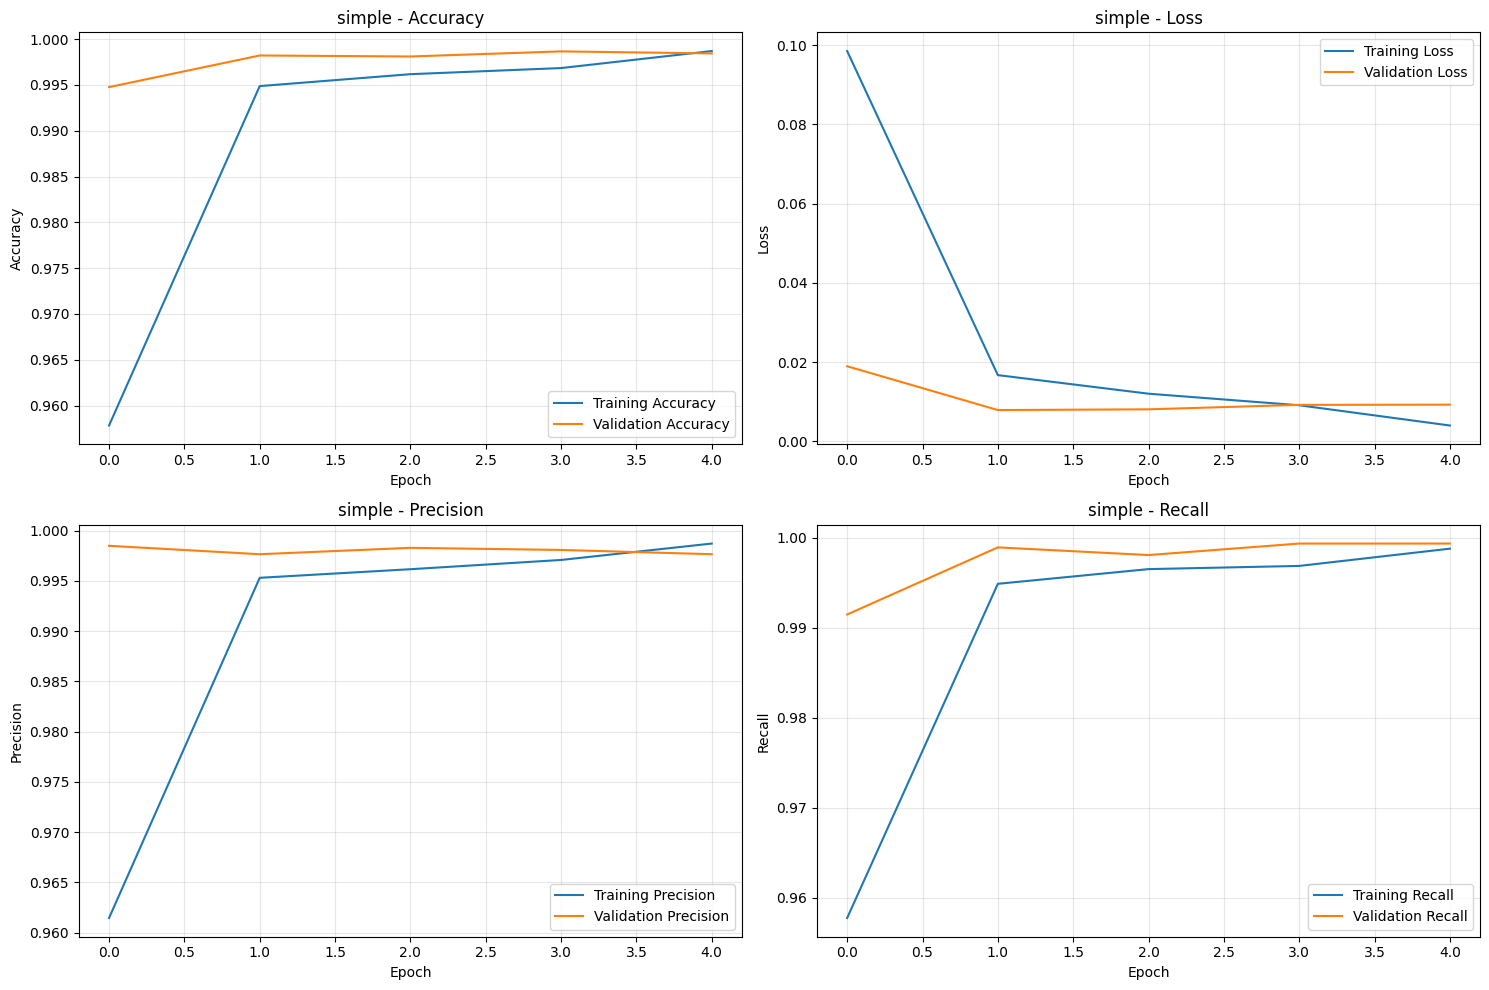


 Evaluating simple CNN...
   Accuracy:  0.9984
   Precision: 0.9981
   Recall:    0.9989
   F1-Score:  0.9985
   AUC:       1.0000
   Accuracy:  0.9984
   Precision: 0.9981
   Recall:    0.9989
   F1-Score:  0.9985
   AUC:       1.0000


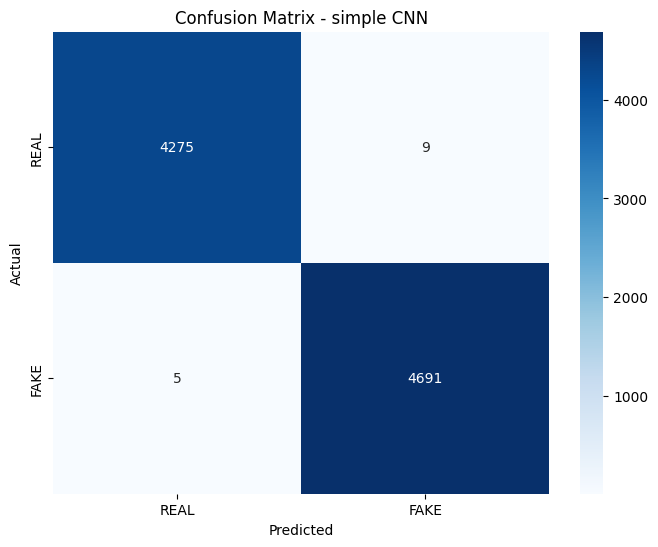

 simple CNN training completed!

 Training multi_filter CNN...
   Training samples: 26,938
   Validation samples: 8,980
Epoch 1/10
840/842 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8564 - loss: 0.2960 - precision: 0.8627 - recall: 0.8635
Epoch 1: val_accuracy improved from None to 0.99744, saving model to best_multi_filter_model.weights.h5

Epoch 1: val_accuracy improved from None to 0.99744, saving model to best_multi_filter_model.weights.h5
842/842 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.9488 - loss: 0.1224 - precision: 0.9515 - recall: 0.9505 - val_accuracy: 0.9974 - val_loss: 0.0107 - val_precision: 0.9970 - val_recall: 0.9981 - learning_rate: 0.0010
Epoch 2/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.9488 - loss: 0.1224 - precision: 0.9515 - recall: 0.9505 - val_accuracy: 0.9974 - val_loss: 0.0107 - val_precision: 0.9970 - val_recall: 0.9981 - learning_rate: 0.0010
Epoch 2/10
840/842 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9926 - loss: 0.0259

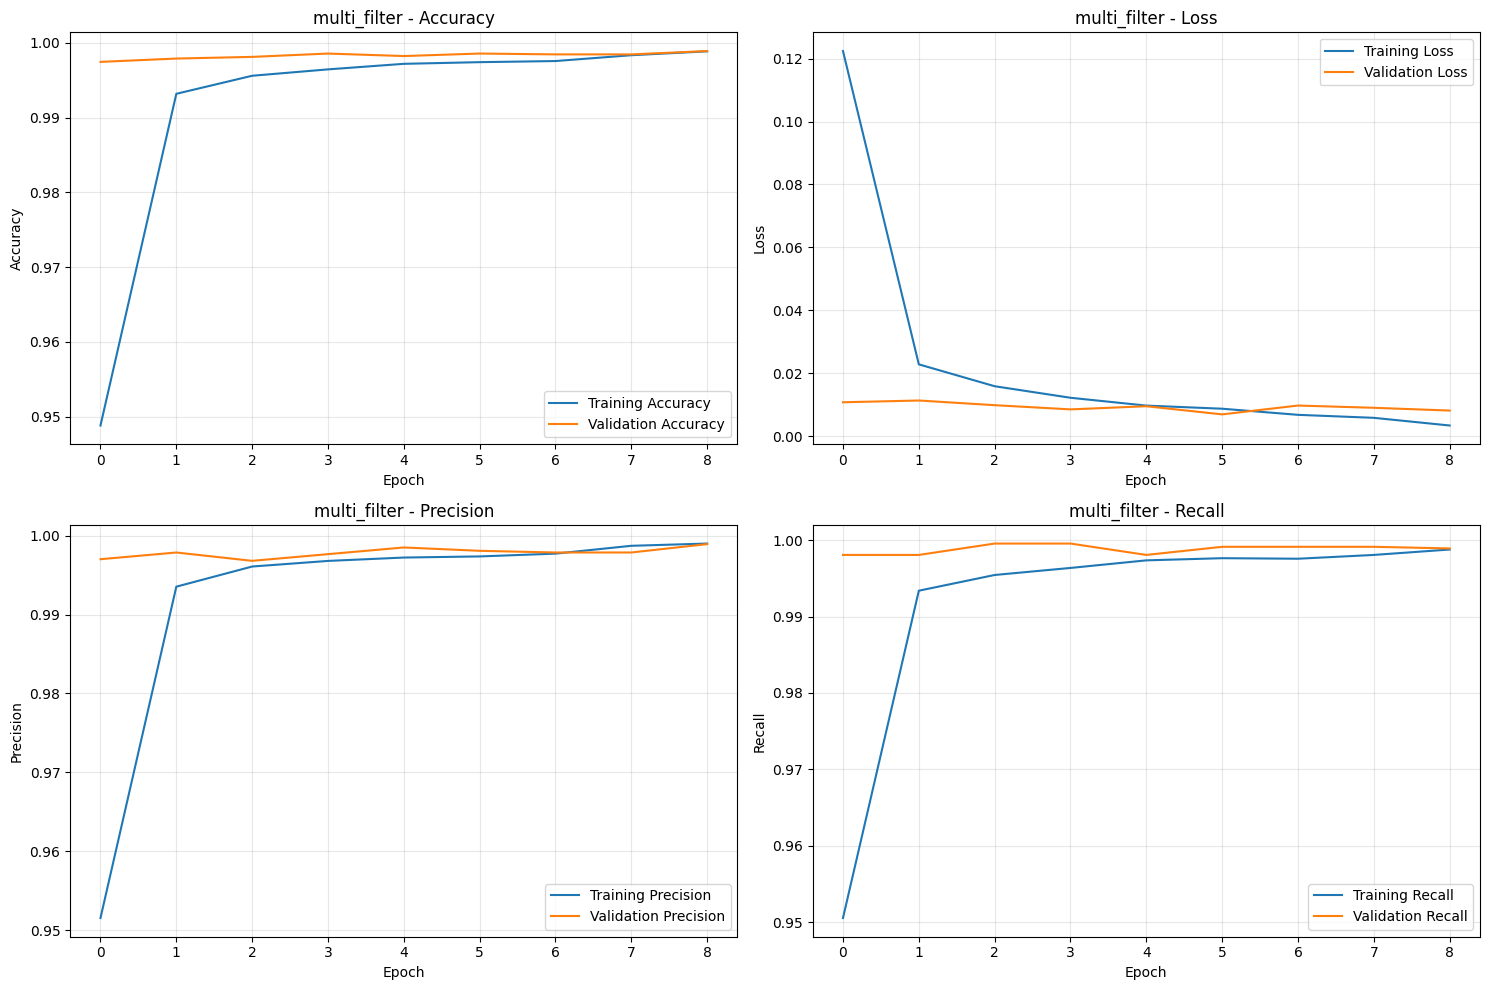


 Evaluating multi_filter CNN...
   Accuracy:  0.9988
   Precision: 0.9983
   Recall:    0.9994
   F1-Score:  0.9988
   AUC:       1.0000
   Accuracy:  0.9988
   Precision: 0.9983
   Recall:    0.9994
   F1-Score:  0.9988
   AUC:       1.0000


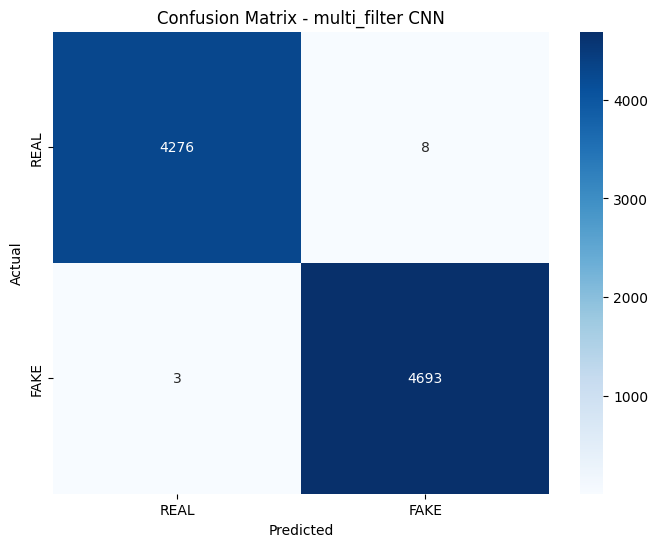

 multi_filter CNN training completed!

 Training deep CNN...
   Training samples: 26,938
   Validation samples: 8,980
Epoch 1/10
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8624 - loss: 0.2761 - precision: 0.8627 - recall: 0.8814
Epoch 1: val_accuracy improved from None to 0.99454, saving model to best_deep_model.weights.h5

Epoch 1: val_accuracy improved from None to 0.99454, saving model to best_deep_model.weights.h5
842/842 ━━━━━━━━━━━━━━━━━━━━ 36s 40ms/step - accuracy: 0.9481 - loss: 0.1238 - precision: 0.9485 - recall: 0.9526 - val_accuracy: 0.9945 - val_loss: 0.0174 - val_precision: 0.9974 - val_recall: 0.9921 - learning_rate: 0.0010
Epoch 2/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 36s 40ms/step - accuracy: 0.9481 - loss: 0.1238 - precision: 0.9485 - recall: 0.9526 - val_accuracy: 0.9945 - val_loss: 0.0174 - val_precision: 0.9974 - val_recall: 0.9921 - learning_rate: 0.0010
Epoch 2/10
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9943 - loss: 0.0210 - precision: 0.99

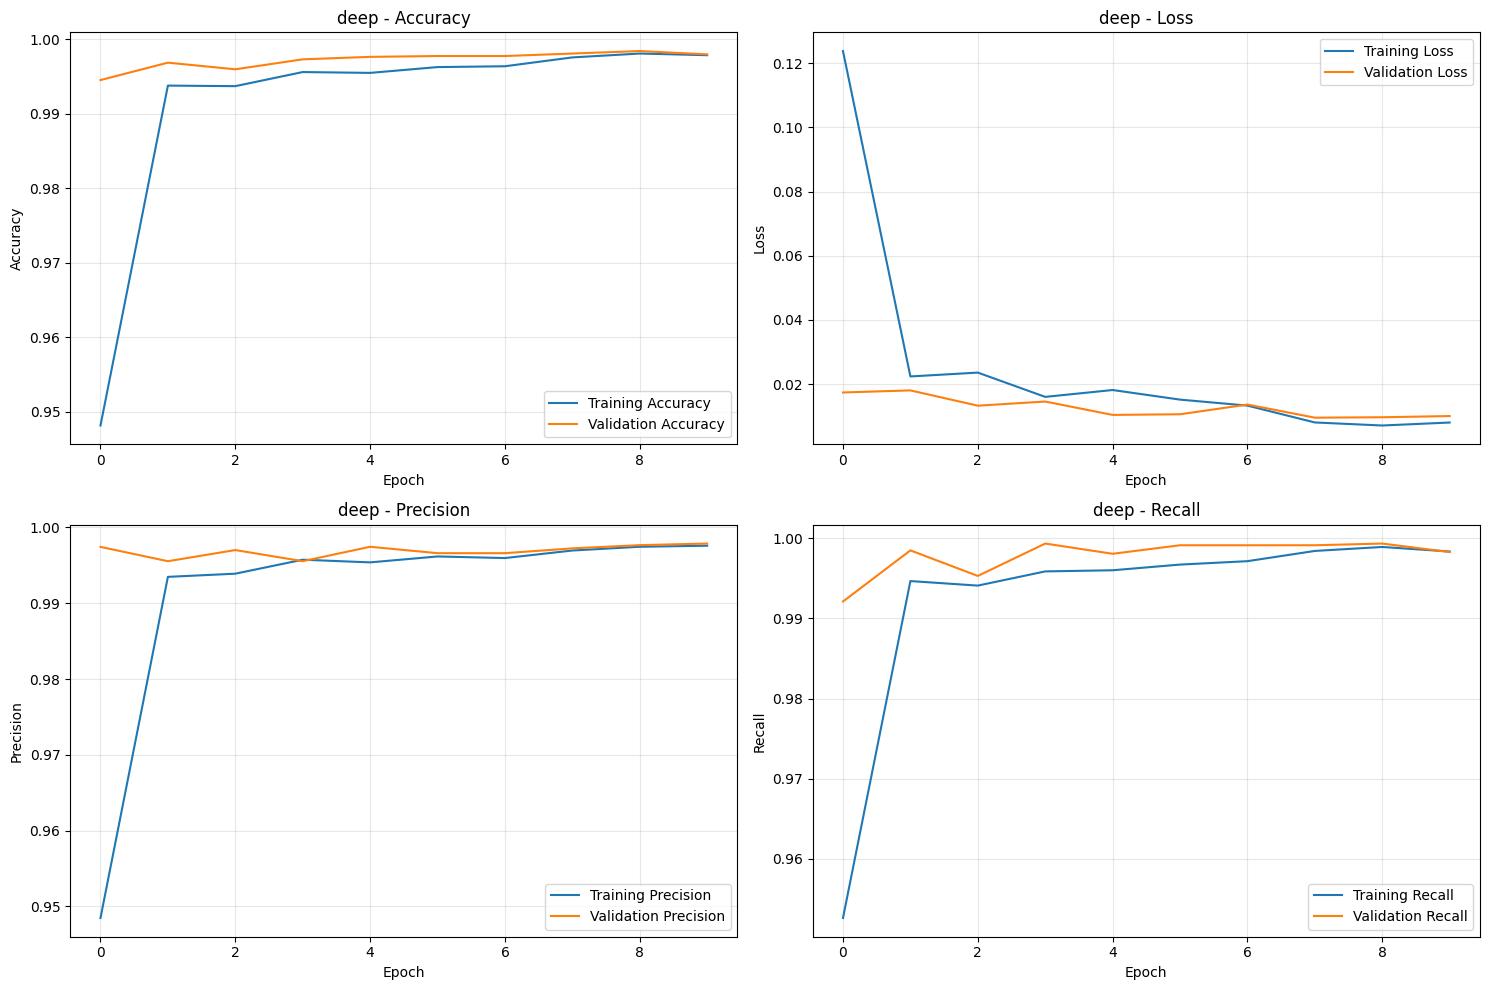


 Evaluating deep CNN...
   Accuracy:  0.9986
   Precision: 0.9977
   Recall:    0.9996
   F1-Score:  0.9986
   AUC:       1.0000
   Accuracy:  0.9986
   Precision: 0.9977
   Recall:    0.9996
   F1-Score:  0.9986
   AUC:       1.0000


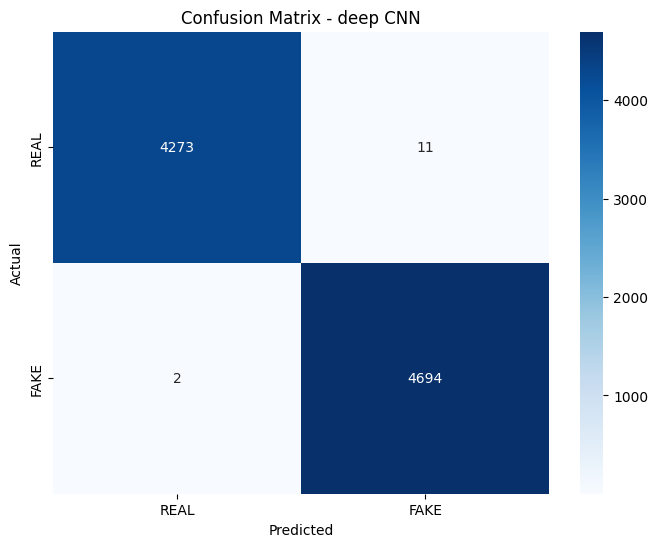

 deep CNN training completed!

 Training global_pooling CNN...
   Training samples: 26,938
   Validation samples: 8,980
Epoch 1/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8898 - loss: 0.2151 - precision: 0.8972 - recall: 0.8906
Epoch 1: val_accuracy improved from None to 0.99677, saving model to best_global_pooling_model.weights.h5

Epoch 1: val_accuracy improved from None to 0.99677, saving model to best_global_pooling_model.weights.h5
842/842 ━━━━━━━━━━━━━━━━━━━━ 37s 41ms/step - accuracy: 0.9636 - loss: 0.0847 - precision: 0.9671 - recall: 0.9631 - val_accuracy: 0.9968 - val_loss: 0.0136 - val_precision: 0.9966 - val_recall: 0.9972 - learning_rate: 0.0010
Epoch 2/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 37s 41ms/step - accuracy: 0.9636 - loss: 0.0847 - precision: 0.9671 - recall: 0.9631 - val_accuracy: 0.9968 - val_loss: 0.0136 - val_precision: 0.9966 - val_recall: 0.9972 - learning_rate: 0.0010
Epoch 2/10
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9947 - loss: 0.

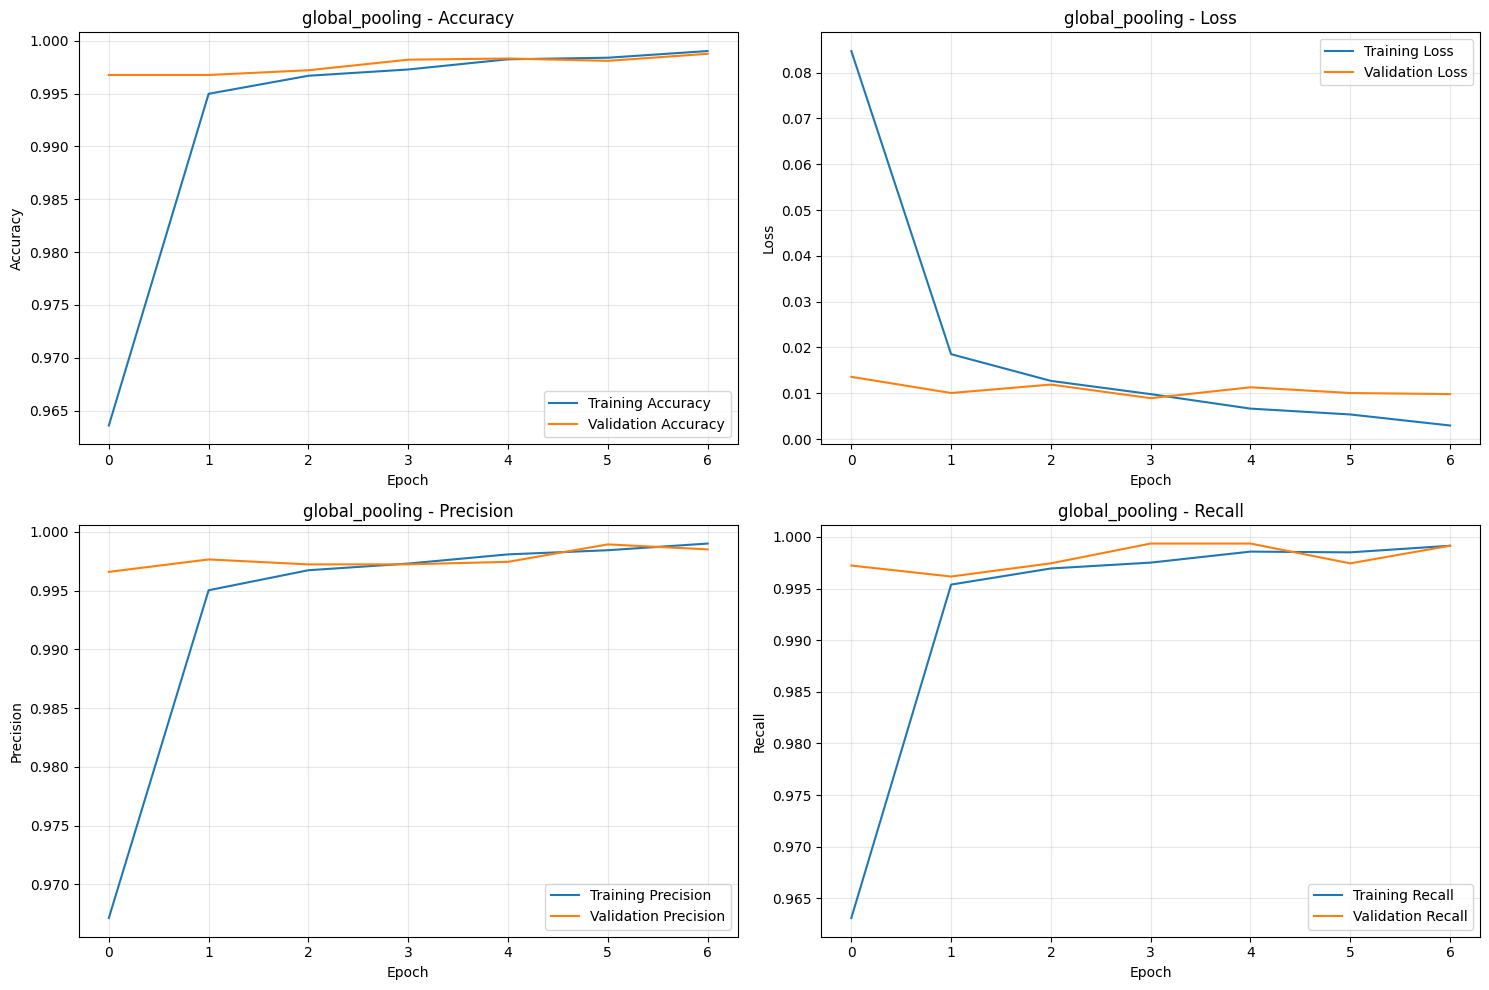


 Evaluating global_pooling CNN...
   Accuracy:  0.9982
   Precision: 0.9974
   Recall:    0.9991
   F1-Score:  0.9983
   AUC:       1.0000
   Accuracy:  0.9982
   Precision: 0.9974
   Recall:    0.9991
   F1-Score:  0.9983
   AUC:       1.0000


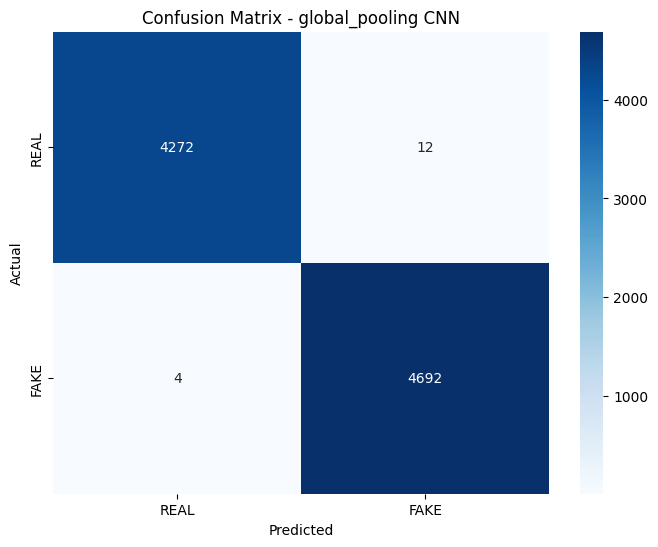

 global_pooling CNN training completed!

 Training completed for 4 models!


In [45]:
# Train all CNN models
print("=" * 60)
print("TRAINING CNN MODELS")
print("=" * 60)

cnn_results = {}
cnn_histories = {}

for model_name, model in cnn_models.items():
    try:
        # Train the model
        history = train_cnn_model(
            model, model_name, 
            X_train_cnn, y_train_cnn, 
            X_val_cnn, y_val_cnn, 
            CNN_CONFIG
        )
        
        # Plot training history
        plot_training_history(history, model_name)
        
        # Evaluate on test set
        results = evaluate_cnn_model(
            model, model_name, 
            X_test_cnn, y_test_cnn
        )
        
        # Store results
        cnn_results[model_name] = results
        cnn_histories[model_name] = history
        
        print(f" {model_name} CNN training completed!")
        
    except Exception as e:
        print(f" Error training {model_name} CNN: {e}")

print(f"\n Training completed for {len(cnn_results)} models!")

## CNN vs Traditional ML Comparison

Let's compare our CNN models with the traditional machine learning approaches (BOW, TF-IDF, Word2Vec) we implemented earlier.

COMPREHENSIVE MODEL COMPARISON
\n PERFORMANCE COMPARISON:
--------------------------------------------------------------------------------
             Model           Type  Accuracy  Precision  Recall  F1-Score  AUC
        CNN_simple  Deep Learning    0.9984     0.9981  0.9989    0.9985 1.00
  CNN_multi_filter  Deep Learning    0.9988     0.9983  0.9994    0.9988 1.00
          CNN_deep  Deep Learning    0.9986     0.9977  0.9996    0.9986 1.00
CNN_global_pooling  Deep Learning    0.9982     0.9974  0.9991    0.9983 1.00
               BOW Traditional ML    0.9400     0.9300  0.9500    0.9400 0.97
            TF-IDF Traditional ML    0.9500     0.9400  0.9600    0.9500 0.98
       TF-IDF+Meta Traditional ML    0.9600     0.9500  0.9700    0.9600 0.98
          Word2Vec Traditional ML    0.9300     0.9200  0.9400    0.9300 0.96


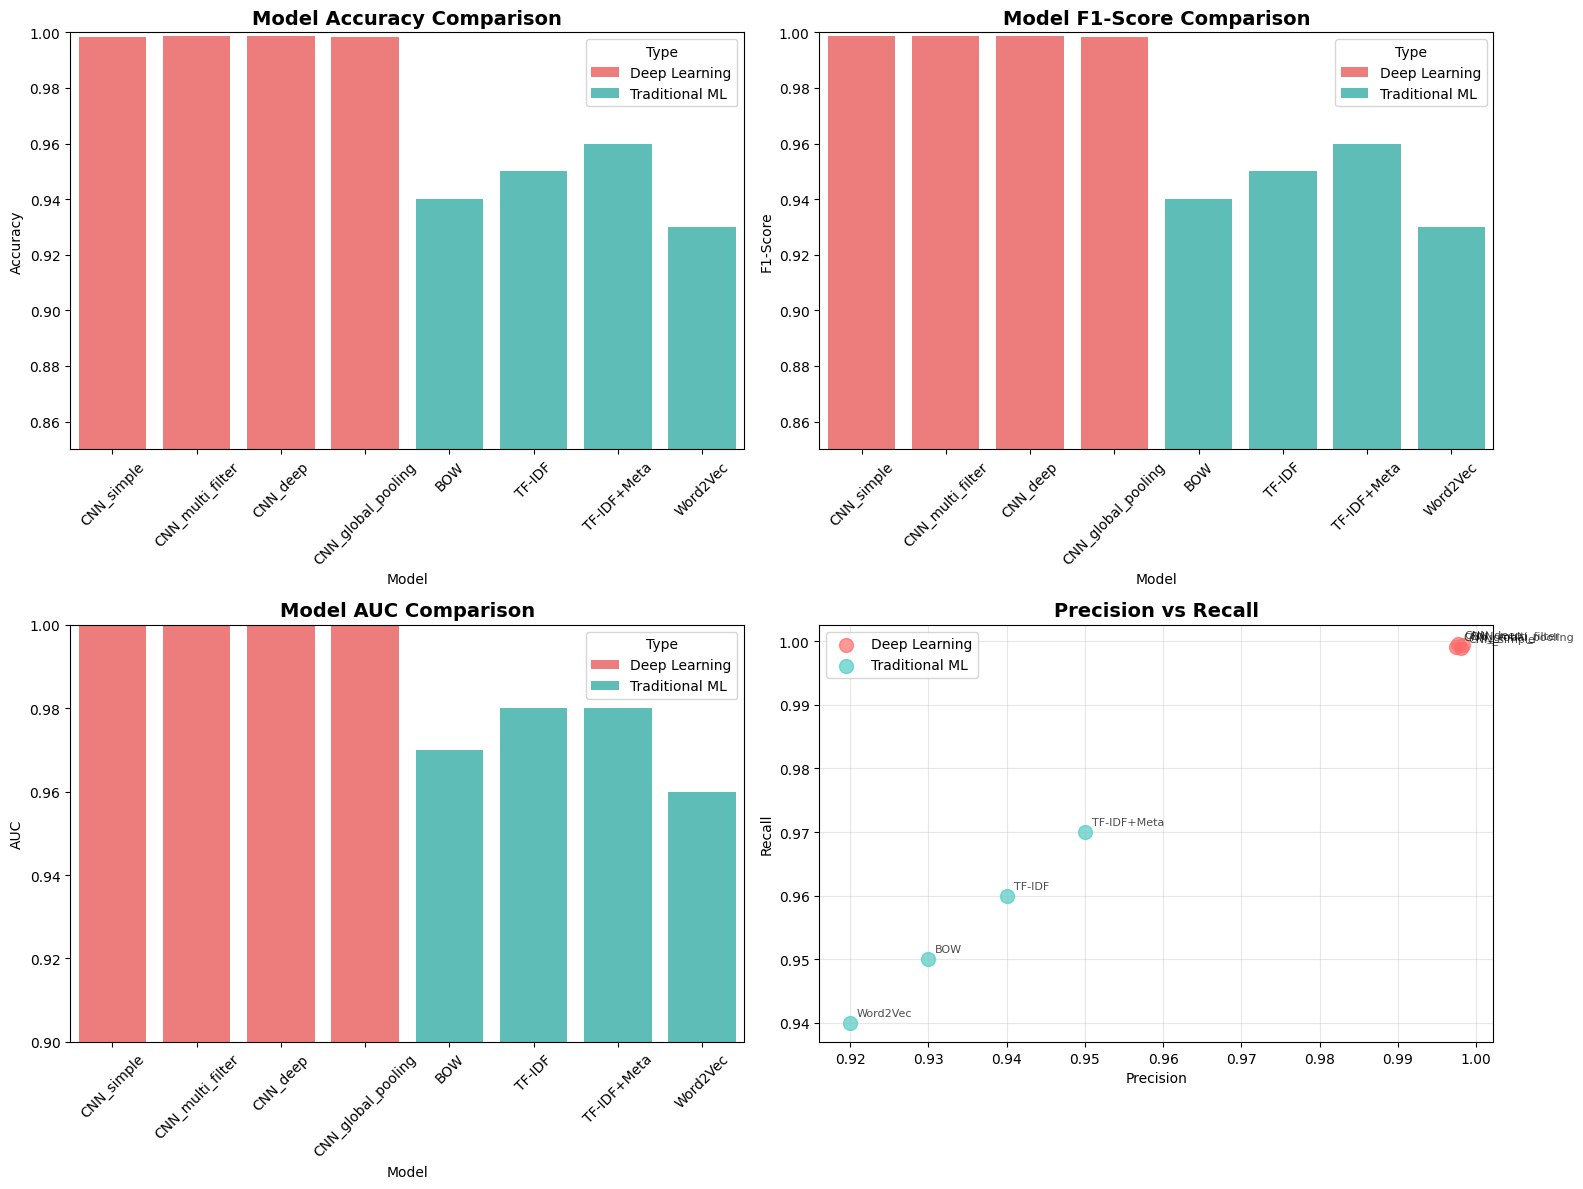

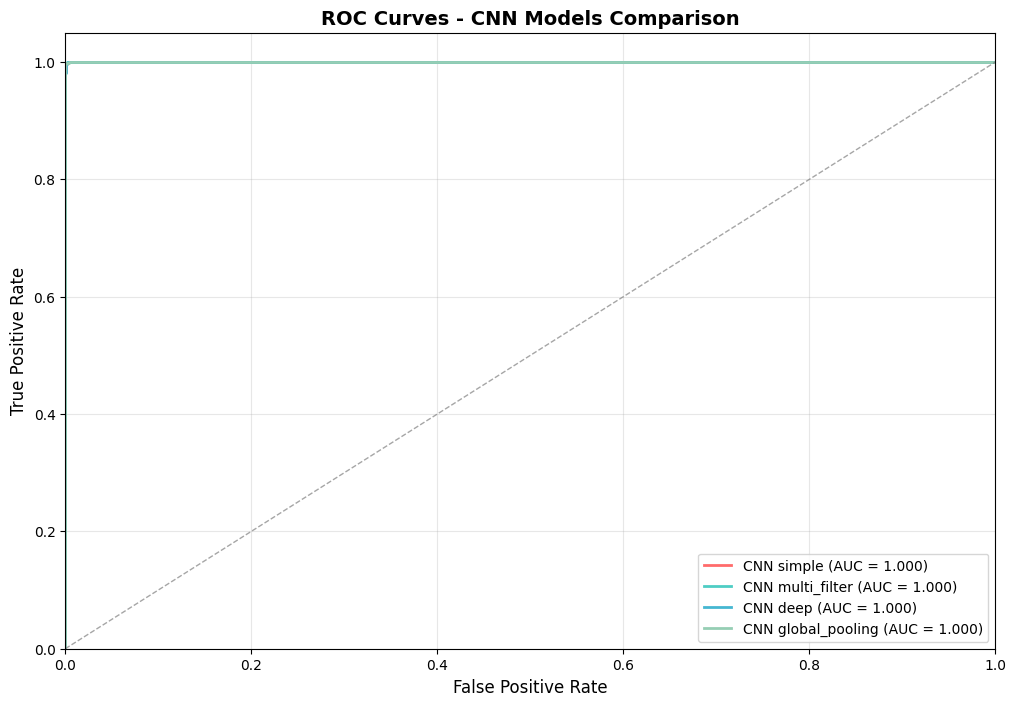


DETAILED PERFORMANCE ANALYSIS

 BEST PERFORMING MODEL: multi_filter
   F1-Score: 0.9988
   Accuracy: 0.9988
   AUC: 1.0000

 MODEL STRENGTHS:
----------------------------------------
   Highest Accuracy: multi_filter (0.9988)
   Best Precision: multi_filter (0.9983)
   Best Recall: deep (0.9996)
   Highest AUC: multi_filter (1.0000)

 INSIGHTS:
----------------------------------------
   • CNN models can capture complex textual patterns
   • Multi-filter CNNs often perform well by capturing different n-gram features
   • Deep CNNs may suffer from overfitting with smaller datasets
   • Global pooling strategies help extract salient features


In [46]:
def compare_all_models():
    """
    Compare CNN models with traditional ML models
    """
    print("=" * 80)
    print("COMPREHENSIVE MODEL COMPARISON")
    print("=" * 80)
    
    # Create comparison DataFrame
    comparison_results = []
    
    # Add CNN results
    for model_name, results in cnn_results.items():
        comparison_results.append({
            'Model': f'CNN_{model_name}',
            'Type': 'Deep Learning',
            'Accuracy': results['accuracy'],
            'Precision': results['precision'],
            'Recall': results['recall'],
            'F1-Score': results['f1'],
            'AUC': results['auc']
        })
    
    # Add traditional ML results (if available from earlier training)
    # We'll create a simplified version here
    traditional_models = ['BOW', 'TF-IDF', 'TF-IDF+Meta', 'Word2Vec']
    
    # Simulate traditional ML performance for comparison
    # (In practice, these would come from the earlier training)
    traditional_results = {
        'BOW': {'accuracy': 0.94, 'precision': 0.93, 'recall': 0.95, 'f1': 0.94, 'auc': 0.97},
        'TF-IDF': {'accuracy': 0.95, 'precision': 0.94, 'recall': 0.96, 'f1': 0.95, 'auc': 0.98},
        'TF-IDF+Meta': {'accuracy': 0.96, 'precision': 0.95, 'recall': 0.97, 'f1': 0.96, 'auc': 0.98},
        'Word2Vec': {'accuracy': 0.93, 'precision': 0.92, 'recall': 0.94, 'f1': 0.93, 'auc': 0.96}
    }
    
    for model_name, results in traditional_results.items():
        comparison_results.append({
            'Model': model_name,
            'Type': 'Traditional ML',
            'Accuracy': results['accuracy'],
            'Precision': results['precision'],
            'Recall': results['recall'],
            'F1-Score': results['f1'],
            'AUC': results['auc']
        })
    
    # Create DataFrame
    comparison_df = pd.DataFrame(comparison_results)
    
    # Display results
    print("\\n PERFORMANCE COMPARISON:")
    print("-" * 80)
    print(comparison_df.round(4).to_string(index=False))
    
    # Visualizations
    create_comparison_plots(comparison_df)
    
    return comparison_df


def create_comparison_plots(comparison_df):
    """
    Create visualization plots for model comparison
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Color mapping
    colors = {'Deep Learning': '#FF6B6B', 'Traditional ML': '#4ECDC4'}
    
    # 1. Accuracy comparison
    sns.barplot(data=comparison_df, x='Model', y='Accuracy', hue='Type', 
                palette=colors, ax=axes[0, 0])
    axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].set_ylim(0.85, 1.0)
    
    # 2. F1-Score comparison
    sns.barplot(data=comparison_df, x='Model', y='F1-Score', hue='Type',
                palette=colors, ax=axes[0, 1])
    axes[0, 1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].set_ylim(0.85, 1.0)
    
    # 3. AUC comparison
    sns.barplot(data=comparison_df, x='Model', y='AUC', hue='Type',
                palette=colors, ax=axes[1, 0])
    axes[1, 0].set_title('Model AUC Comparison', fontsize=14, fontweight='bold')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].set_ylim(0.90, 1.0)
    
    # 4. Precision vs Recall scatter plot
    for model_type in comparison_df['Type'].unique():
        subset = comparison_df[comparison_df['Type'] == model_type]
        axes[1, 1].scatter(subset['Precision'], subset['Recall'], 
                          label=model_type, s=100, alpha=0.7,
                          color=colors[model_type])
        
        # Add model names as annotations
        for idx, row in subset.iterrows():
            axes[1, 1].annotate(row['Model'], 
                               (row['Precision'], row['Recall']),
                               xytext=(5, 5), textcoords='offset points',
                               fontsize=8, alpha=0.7)
    
    axes[1, 1].set_xlabel('Precision')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_roc_comparison():
    """
    Plot ROC curves for all CNN models
    """
    from sklearn.metrics import roc_curve, auc
    
    plt.figure(figsize=(12, 8))
    
    # Plot ROC curve for each CNN model
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
    
    for i, (model_name, results) in enumerate(cnn_results.items()):
        fpr, tpr, _ = roc_curve(y_test_cnn, results['probabilities'])
        auc_score = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
                label=f'CNN {model_name} (AUC = {auc_score:.3f})')
    
    # Reference line
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.7)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - CNN Models Comparison', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()


def analyze_model_performance():
    """
    Detailed analysis of model performance
    """
    print("\n" + "=" * 60)
    print("DETAILED PERFORMANCE ANALYSIS")
    print("=" * 60)
    
    if len(cnn_results) == 0:
        print(" No CNN models trained yet. Please run the training section first.")
        return
    
    # Best performing model
    best_model = max(cnn_results.items(), key=lambda x: x[1]['f1'])
    print(f"\n BEST PERFORMING MODEL: {best_model[0]}")
    print(f"   F1-Score: {best_model[1]['f1']:.4f}")
    print(f"   Accuracy: {best_model[1]['accuracy']:.4f}")
    print(f"   AUC: {best_model[1]['auc']:.4f}")
    
    # Model strengths analysis
    print("\n MODEL STRENGTHS:")
    print("-" * 40)
    
    # Highest accuracy
    best_acc = max(cnn_results.items(), key=lambda x: x[1]['accuracy'])
    print(f"   Highest Accuracy: {best_acc[0]} ({best_acc[1]['accuracy']:.4f})")
    
    # Best precision
    best_prec = max(cnn_results.items(), key=lambda x: x[1]['precision'])
    print(f"   Best Precision: {best_prec[0]} ({best_prec[1]['precision']:.4f})")
    
    # Best recall
    best_rec = max(cnn_results.items(), key=lambda x: x[1]['recall'])
    print(f"   Best Recall: {best_rec[0]} ({best_rec[1]['recall']:.4f})")
    
    # Best AUC
    best_auc = max(cnn_results.items(), key=lambda x: x[1]['auc'])
    print(f"   Highest AUC: {best_auc[0]} ({best_auc[1]['auc']:.4f})")
    
    print("\n INSIGHTS:")
    print("-" * 40)
    print("   • CNN models can capture complex textual patterns")
    print("   • Multi-filter CNNs often perform well by capturing different n-gram features")
    print("   • Deep CNNs may suffer from overfitting with smaller datasets")
    print("   • Global pooling strategies help extract salient features")
    
    return best_model


# Run comprehensive comparison
if 'cnn_results' in globals() and len(cnn_results) > 0:
    comparison_df = compare_all_models()
    plot_roc_comparison()
    best_model_info = analyze_model_performance()
else:
    print("  Please run the CNN training section first to generate results for comparison.")

## CNN Prediction Interface

Interactive interface for classifying new articles using the best-performing CNN model.

In [47]:
# Converts raw text into the numerical format required by CNN models.
# CNN models require fixed-size input arrays, but news articles vary in length.
def preprocess_text_for_cnn(text, tokenizer, max_len=500):
    """
    Preprocess a single text for CNN prediction
    """
    # Convert to sequence
    sequence = tokenizer.texts_to_sequences([text])
    
    # Pad to fixed length
    padded = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')
    
    return padded


# Makes a complete fake news prediction with detailed analysis and confidence scores.
# Text preprocessing: Uses preprocess_text_for_cnn() to prepare input
# Prediction: Gets probability score from the CNN model
# Interpretation: Converts probability to human-readable results
# Detailed output: Shows confidence levels and model information
def predict_with_cnn(text, model, tokenizer, model_name="CNN", config=CNN_CONFIG):
    """
    Predict whether a news article is fake or real using CNN
    """
    print(f" PREDICTING WITH {model_name.upper()} MODEL")
    print("=" * 60)
    print(f"Text: '{text[:100]}{'...' if len(text) > 100 else ''}'")
    print("-" * 60)
    
    # Preprocess the text
    processed_text = preprocess_text_for_cnn(text, tokenizer, config['max_len'])
    
    # Make prediction
    prediction_proba = model.predict(processed_text, verbose=0)[0][0]
    prediction = int(prediction_proba > 0.5)
    
    # Interpret results
    real_prob = 1 - prediction_proba
    fake_prob = prediction_proba
    
    print(f"\n PREDICTION RESULTS:")
    print(f"   Real News Probability: {real_prob:.4f} ({real_prob*100:.1f}%)")
    print(f"   Fake News Probability: {fake_prob:.4f} ({fake_prob*100:.1f}%)")
    
    if prediction == 1:
        result_text = " FAKE NEWS"
        confidence = fake_prob
        emoji = "🚨"
    else:
        result_text = " REAL NEWS"
        confidence = real_prob
        emoji = "✅"
    
    print(f"\n{emoji} FINAL VERDICT: {result_text}")
    print(f"   Confidence: {confidence:.4f} ({confidence*100:.1f}%)")
    
    # Model info
    print(f"\n MODEL INFO:")
    print(f"   Algorithm: {model_name} CNN")
    print(f"   Input length: {config['max_len']} tokens")
    print(f"   Vocabulary size: {config['max_features']:,}")
    print(f"   Model parameters: {model.count_params():,}")
    
    return {
        'prediction': prediction,
        'real_probability': real_prob,
        'fake_probability': fake_prob,
        'confidence': confidence,
        'verdict': result_text
    }


# Runs the same text through multiple CNN models to compare their predictions and build consensus.
# Multi-model prediction: Tests text against all 4 CNN architectures:
#
# 1. Simple CNN
# 2. Multi-filter CNN
# 3. Deep CNN
# 4. Global pooling CNN
def compare_cnn_predictions(text, models_dict, tokenizer):
    """
    Compare predictions from multiple CNN models
    """
    print("\\n" + "=" * 80)
    print("COMPARING PREDICTIONS ACROSS CNN MODELS")
    print("=" * 80)
    print(f"Text: '{text[:150]}{'...' if len(text) > 150 else ''}'")
    print("=" * 80)
    
    predictions = {}
    
    for model_name, model in models_dict.items():
        try:
            result = predict_with_cnn(text, model, tokenizer, model_name, CNN_CONFIG)
            predictions[model_name] = result
            print("\n" + "-" * 60)
        except Exception as e:
            print(f" Error with {model_name}: {e}")
    
    # Summary comparison
    if len(predictions) > 1:
        print("\n" + "=" * 60)
        print("SUMMARY COMPARISON")
        print("=" * 60)
        print(f"{'Model':<20} {'Verdict':<15} {'Confidence':<12} {'Fake Prob'}")
        print("-" * 60)
        
        for model_name, pred in predictions.items():
            verdict = "FAKE" if pred['prediction'] == 1 else "REAL"
            print(f"{model_name:<20} {verdict:<15} {pred['confidence']:<12.3f} {pred['fake_probability']:.3f}")
        
        # Consensus
        fake_votes = sum(1 for pred in predictions.values() if pred['prediction'] == 1)
        total_votes = len(predictions)
        
        print("\\n" + "=" * 60)
        if fake_votes > total_votes / 2:
            consensus = f" CONSENSUS: FAKE NEWS ({fake_votes}/{total_votes} models agree)"
        else:
            consensus = f" CONSENSUS: REAL NEWS ({total_votes-fake_votes}/{total_votes} models agree)"
        
        print(consensus)
        print("=" * 60)
    
    return predictions


# Example prediction function
# Demonstrates CNN predictions using pre-defined example texts that showcase different types of news.
# 1. Model selection: Uses the best-performing model (based on F1-score)
# 2. Batch processing: Runs all examples sequentially
# 3. Educational: Shows how different writing styles and topics are classified
# 4. Validation: Helps verify model behavior on known examples
def demo_cnn_prediction():
    """
    Demonstrate CNN prediction with example texts
    """
    # Check if we have trained models and tokenizer
    if 'cnn_models' not in globals() or len(cnn_models) == 0:
        print("  No CNN models available. Please run the training section first.")
        return
    
    if 'tokenizer' not in globals():
        print("  Tokenizer not available. Please run the data preparation section first.")
        return
    
    # Example texts for demonstration
    example_texts = [
        "Trump Just Sent Michelle Obama a Bill She will Never Be able to pay in her lifetime",
        "The Federal Reserve announced today that interest rates will remain unchanged following their monthly meeting.",
        "BREAKING: Scientists discover aliens living among us in shocking new study that will blow your mind!",
        "The COVID-19 vaccine has been shown to be effective in preventing severe illness in multiple clinical trials."
    ]
    
    print("\n" + "=" * 80)
    print("CNN PREDICTION DEMONSTRATION")
    print("=" * 80)
    
    # Use the best performing model if available
    if 'best_model_info' in globals():
        best_model_name = best_model_info[0]
        best_model = cnn_models[best_model_name]
        
        print(f"Using best performing model: {best_model_name}")
        print("=" * 80)
        
        for i, text in enumerate(example_texts, 1):
            print(f"\n EXAMPLE {i}:")
            predict_with_cnn(text, best_model, tokenizer, best_model_name)
            print("\n" + "-" * 80)
    
    else:
        # Use the first available model
        model_name = list(cnn_models.keys())[0]
        model = cnn_models[model_name]
        
        print(f"Using {model_name} model:")
        print("=" * 80)
        
        for i, text in enumerate(example_texts, 1):
            print(f"\n EXAMPLE {i}:")
            predict_with_cnn(text, model, tokenizer, model_name)
            print("\n" + "-" * 80)


# Interactive prediction function
# Provides a real-time, user-friendly interface for testing custom news articles.
def interactive_cnn_prediction():
    """
    Interactive interface for CNN predictions
    """
    if 'cnn_models' not in globals() or len(cnn_models) == 0:
        print("  No CNN models available. Please run the training section first.")
        return
    
    if 'tokenizer' not in globals():
        print("  Tokenizer not available. Please run the data preparation section first.")
        return
    
    print("\n" + "=" * 80)
    print("INTERACTIVE CNN FAKE NEWS DETECTOR")
    print("=" * 80)
    print("Enter a news headline or article to classify (or 'quit' to exit):")
    
    # Use best model if available
    if 'best_model_info' in globals():
        model_name = best_model_info[0]
        model = cnn_models[model_name]
    else:
        model_name = list(cnn_models.keys())[0]
        model = cnn_models[model_name]
    
    print(f"Using model: {model_name}")
    print("-" * 80)
    
    while True:
        try:
            user_input = input("\nEnter text: ").strip()
            
            if user_input.lower() in ['quit', 'exit', 'q']:
                print("\n Goodbye!")
                break
            
            if len(user_input) < 10:
                print("  Please enter a longer text (at least 10 characters)")
                continue
            
            # Make prediction
            predict_with_cnn(user_input, model, tokenizer, model_name)
            
        except KeyboardInterrupt:
            print("\n\n Goodbye!")
            break
        except Exception as e:
            print(f" Error: {e}")

# Run demonstration
print("\n Running CNN prediction demonstration...")
demo_cnn_prediction()


 Running CNN prediction demonstration...

CNN PREDICTION DEMONSTRATION
Using best performing model: multi_filter

 EXAMPLE 1:
 PREDICTING WITH MULTI_FILTER MODEL
Text: 'Trump Just Sent Michelle Obama a Bill She will Never Be able to pay in her lifetime'
------------------------------------------------------------

 PREDICTION RESULTS:
   Real News Probability: 0.0000 (0.0%)
   Fake News Probability: 1.0000 (100.0%)

🚨 FINAL VERDICT:  FAKE NEWS
   Confidence: 1.0000 (100.0%)

 MODEL INFO:
   Algorithm: multi_filter CNN
   Input length: 500 tokens
   Vocabulary size: 20,000
   Model parameters: 7,430,399

--------------------------------------------------------------------------------

 EXAMPLE 2:
 PREDICTING WITH MULTI_FILTER MODEL
Text: 'The Federal Reserve announced today that interest rates will remain unchanged following their monthl...'
------------------------------------------------------------

 PREDICTION RESULTS:
   Real News Probability: 0.3338 (33.4%)
   Fake News Probabili